In [1]:
from pathlib import Path
import os
import sys 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.append(str(ROOT/"src"))
RAW_DATA_FILE = ROOT/'src'/'data'/'raw'/'loan_dataset_20000.csv'
print(ROOT)
print(RAW_DATA_FILE)

from utils.plot_continuo import *
from utils.plot_categorico import *

/home/jair/Proyectos/Loan_Status_Prediction
/home/jair/Proyectos/Loan_Status_Prediction/src/data/raw/loan_dataset_20000.csv


In [2]:
df = pd.read_csv(RAW_DATA_FILE)
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


## Análisis de los datos

In [3]:
variable_objetivo = 'loan_paid_back'
print(df.shape)
df.info()

(20000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,20000.0,NaN,NaN,NaN,48.027,15.829352,21.0,35.0,48.0,62.0,75.0
gender,20000,3,Female,10034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,20000,4,Single,9031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,20000,5,Bachelor's,8045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,20000.0,NaN,NaN,NaN,43549.637765,28668.579671,6000.0,24260.7525,36585.26,54677.9175,400000.0
monthly_income,20000.0,NaN,NaN,NaN,3629.136466,2389.048326,500.0,2021.73,3048.77,4556.495,33333.33
employment_status,20000,5,Employed,13007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
debt_to_income_ratio,20000.0,NaN,NaN,NaN,0.177019,0.105059,0.01,0.096,0.16,0.241,0.667
credit_score,20000.0,NaN,NaN,NaN,679.25695,69.63858,373.0,632.0,680.0,727.0,850.0
loan_amount,20000.0,NaN,NaN,NaN,15129.300909,8605.405513,500.0,8852.695,14946.17,20998.8675,49039.69


## Variable objetivo


In [5]:
df[variable_objetivo].value_counts()

loan_paid_back
1    15998
0     4002
Name: count, dtype: int64

/home/jair/Proyectos/Loan_Status_Prediction/src/utils/plot_categorico.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/home/jair/Proyectos/Loan_Status_Prediction/src/utils/plot_categorico.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([negative_tick, positive_tick])


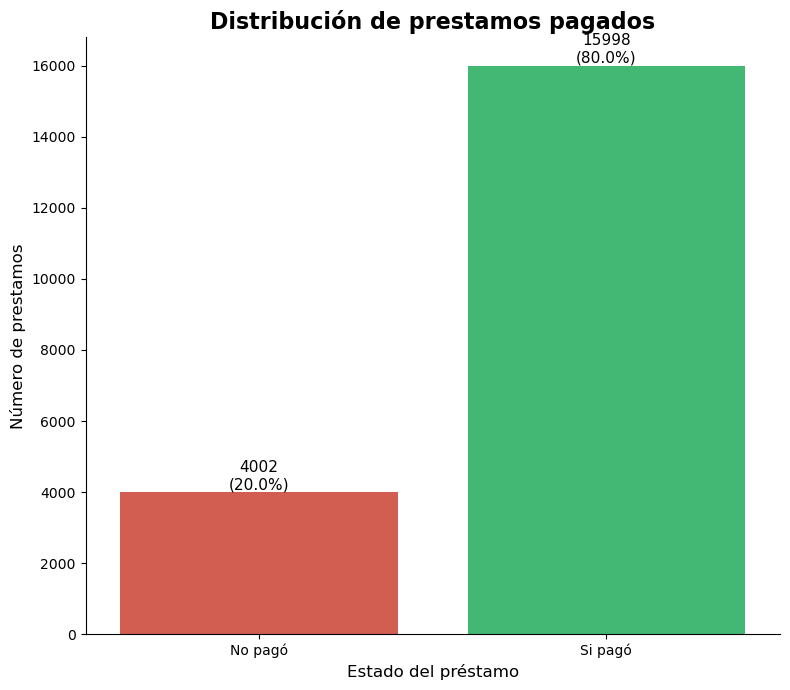

In [6]:
variable_objetivo = 'loan_paid_back'
plot_hist_variable_binaria(df, variable_objetivo,
                            'Estado del préstamo',
                            'Número de prestamos',
                            'Si pagó', 'No pagó',
                            'Distribución de prestamos pagados')

### Separación del tipo de variables

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != variable_objetivo]
categoric_cols = [col for col in df.columns if col not in numeric_cols]

print('Numéricas')
print(numeric_cols)
print(f'total: {len(numeric_cols)}')
print('Categóricas')
print(categoric_cols)
print(f'total: {len(categoric_cols)}')

Numéricas
['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']
total: 15
Categóricas
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']
total: 7


### Corrección del tipo de columnas

In [8]:
real_categoric = ['loan_term', 'public_records']
numeric_cols = [col for col in numeric_cols if col not in real_categoric]
categoric_cols = categoric_cols + real_categoric

print('----- Numéricas -----')
for num_col in numeric_cols:
    print(f'\t{num_col}')
print(f'total: {len(numeric_cols)}')

print('\n----- Categóricas -----')
for cat_col in categoric_cols:
    print(f'\t{cat_col}')
print(f'total: {len(categoric_cols)}')

----- Numéricas -----
	age
	annual_income
	monthly_income
	debt_to_income_ratio
	credit_score
	loan_amount
	interest_rate
	installment
	num_of_open_accounts
	total_credit_limit
	current_balance
	delinquency_history
	num_of_delinquencies
total: 13

----- Categóricas -----
	gender
	marital_status
	education_level
	employment_status
	loan_purpose
	grade_subgrade
	loan_paid_back
	loan_term
	public_records
total: 9


## Variables numéricas

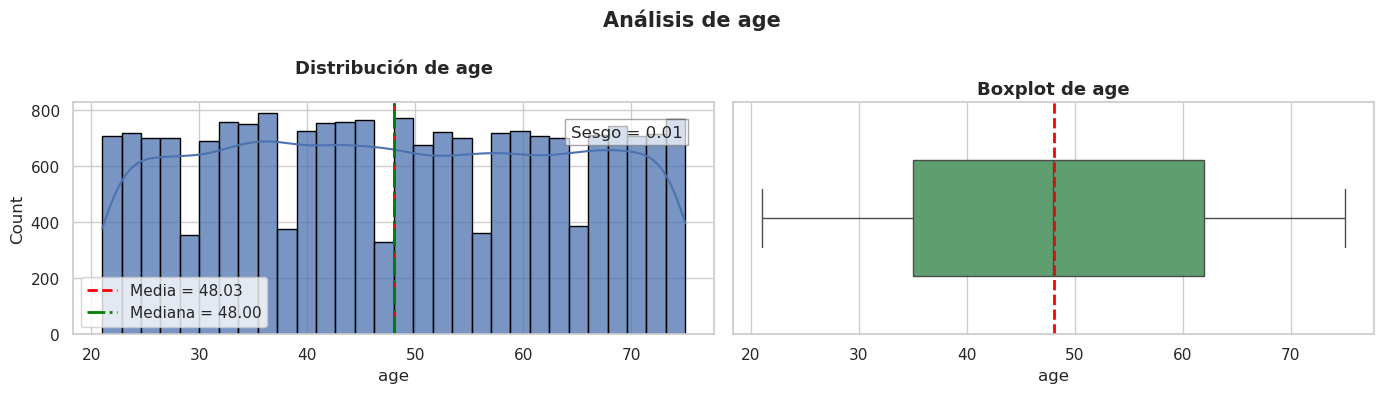

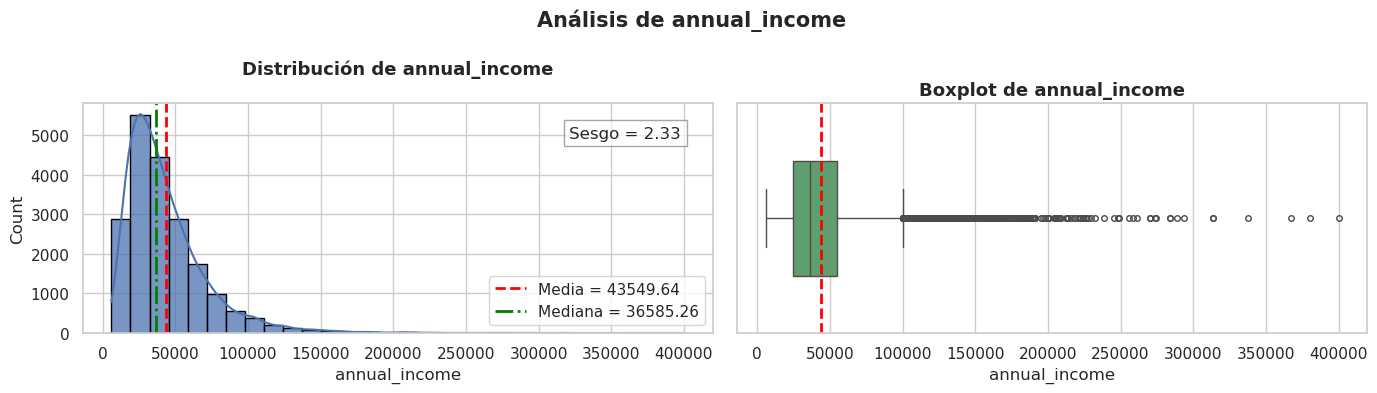

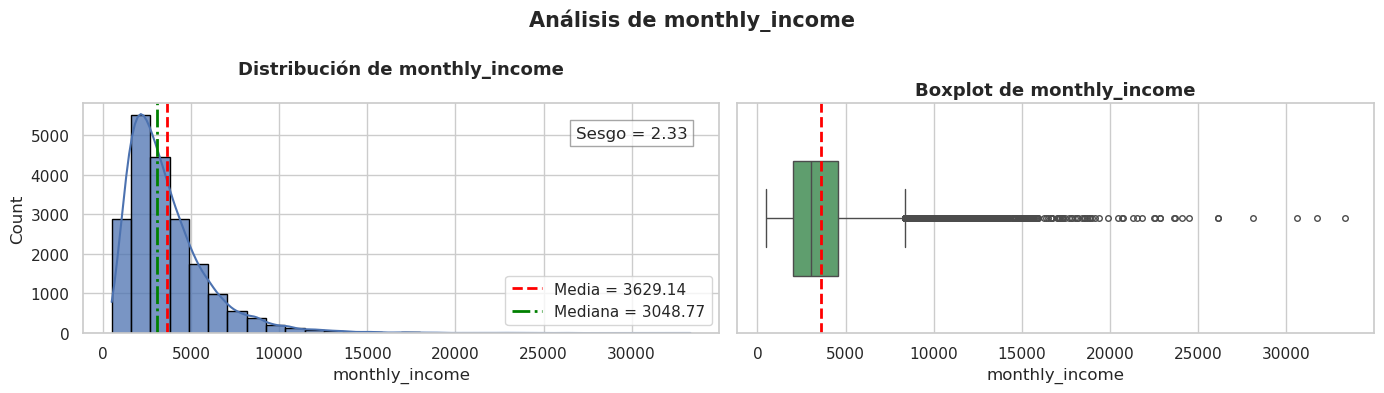

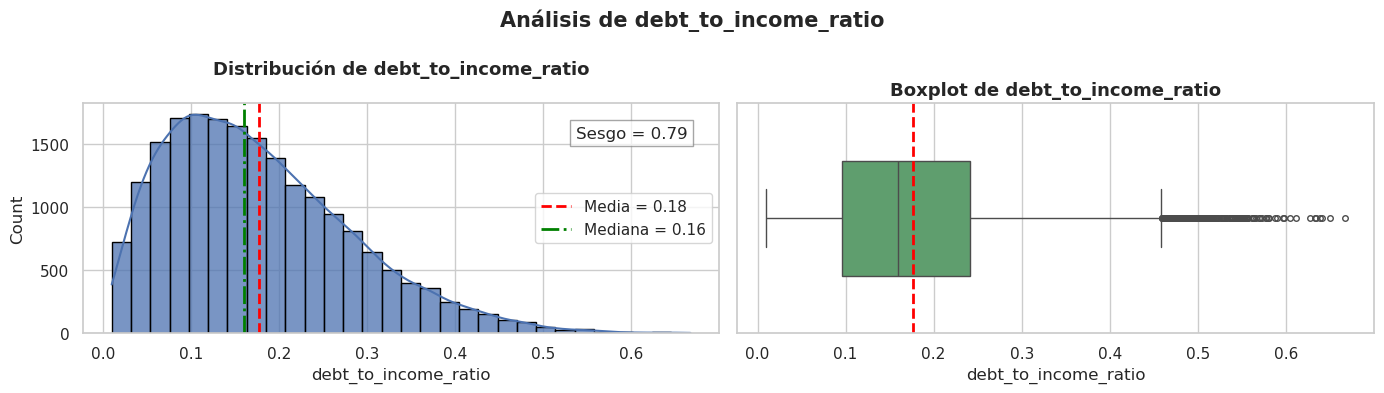

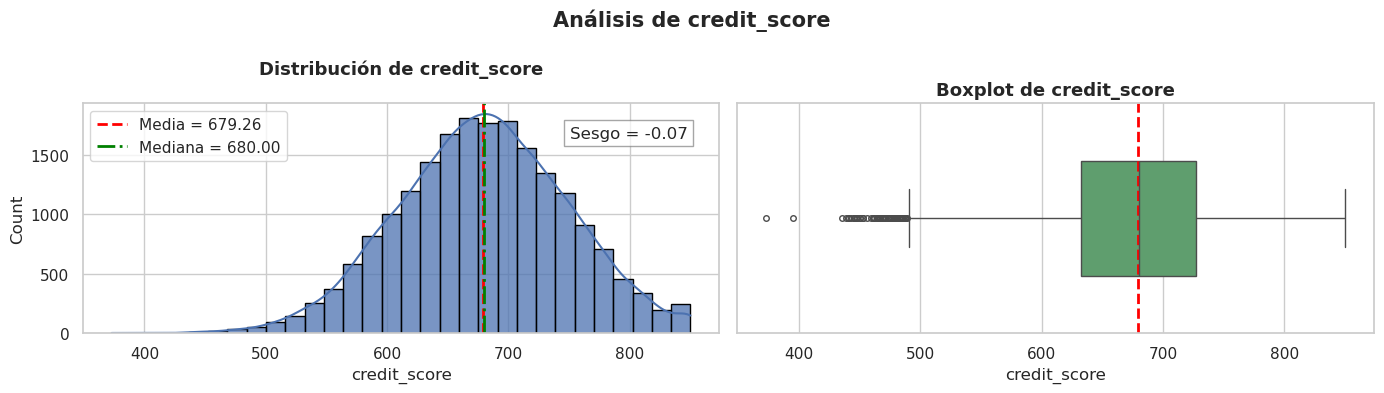

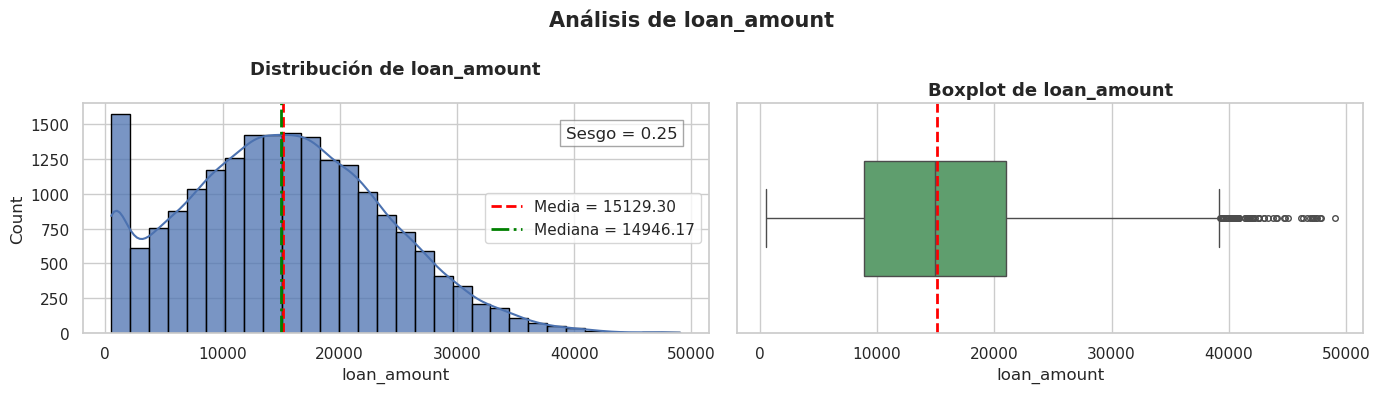

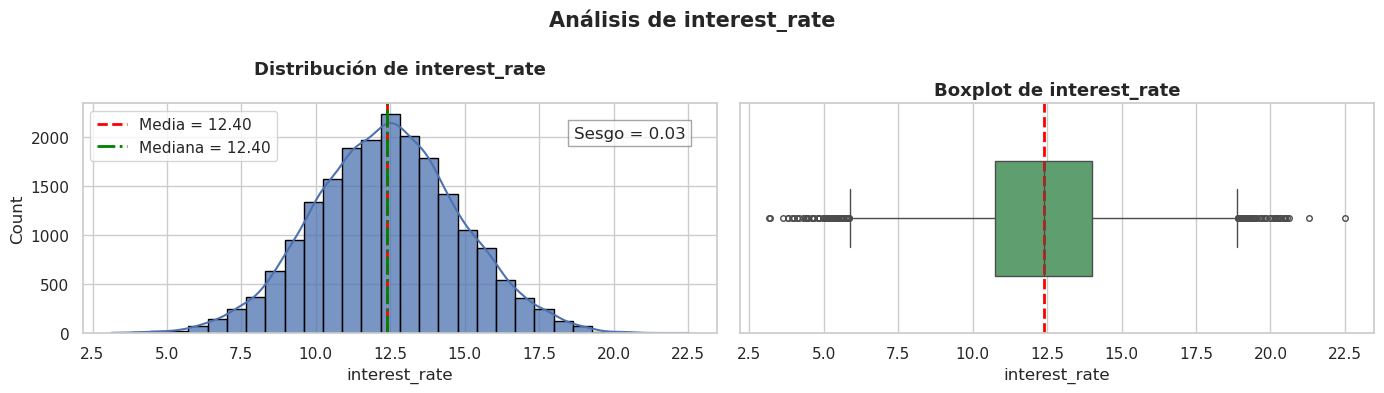

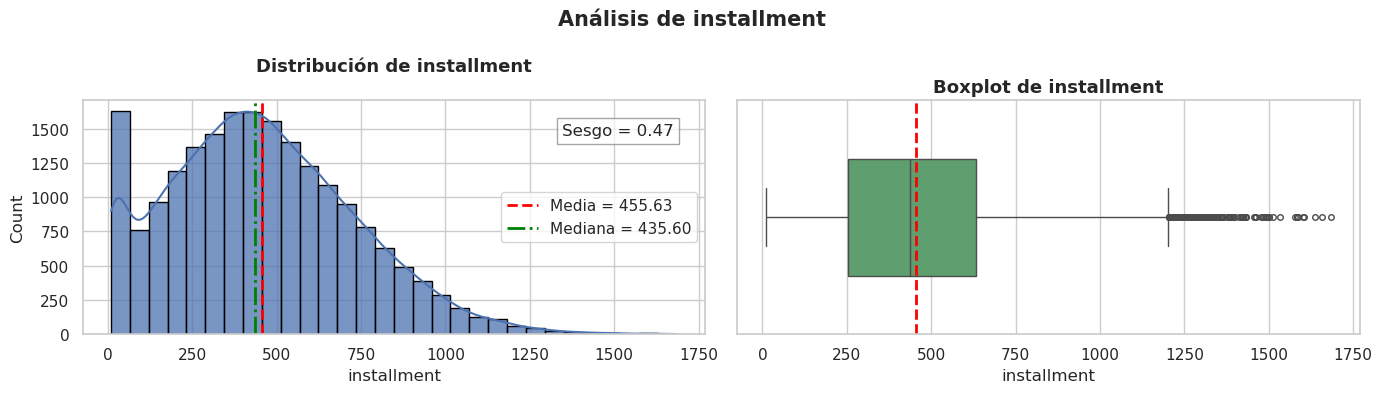

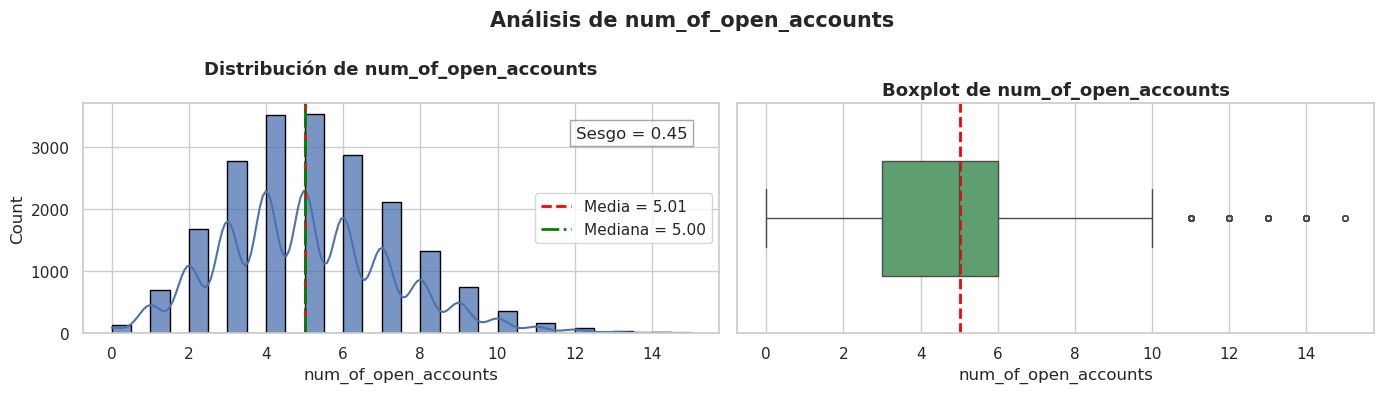

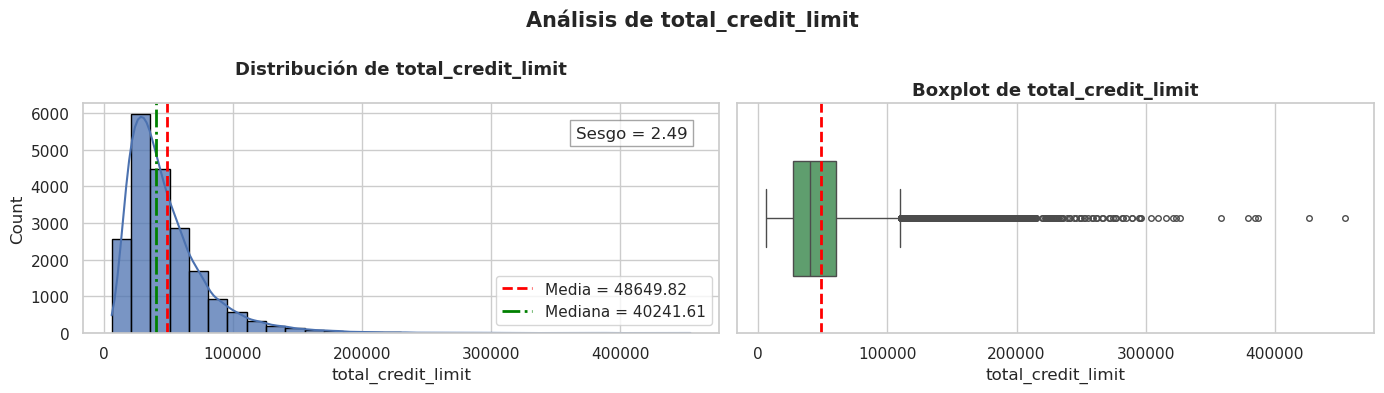

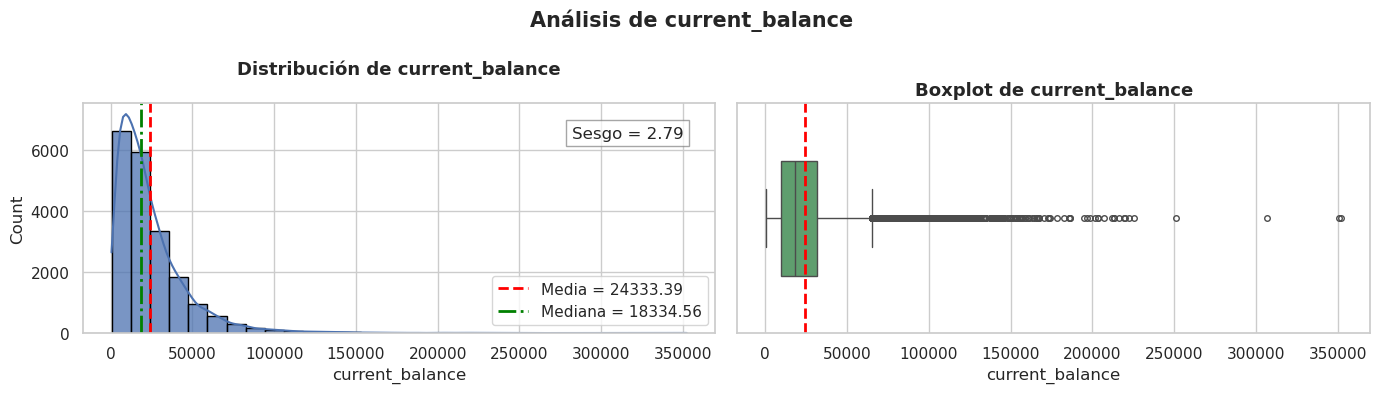

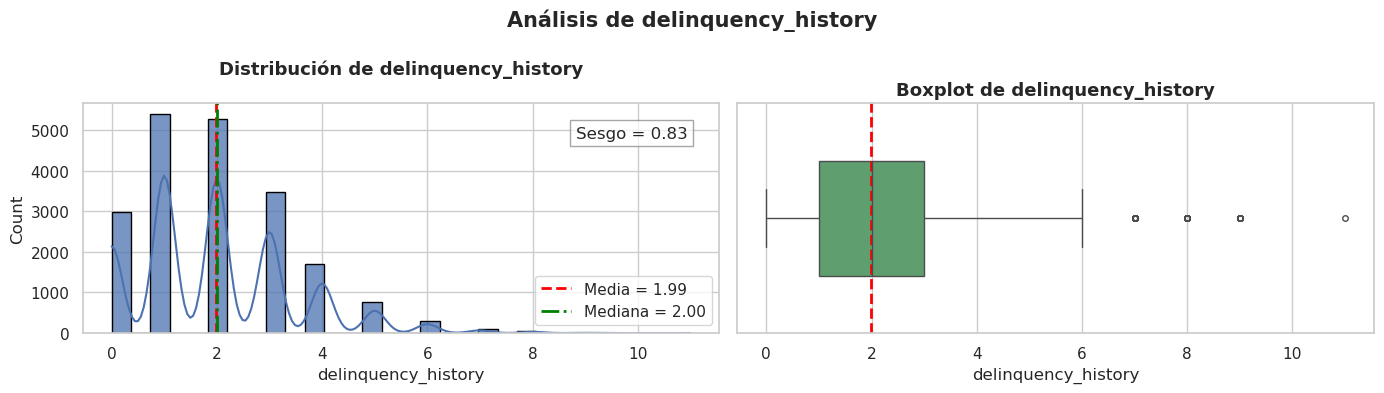

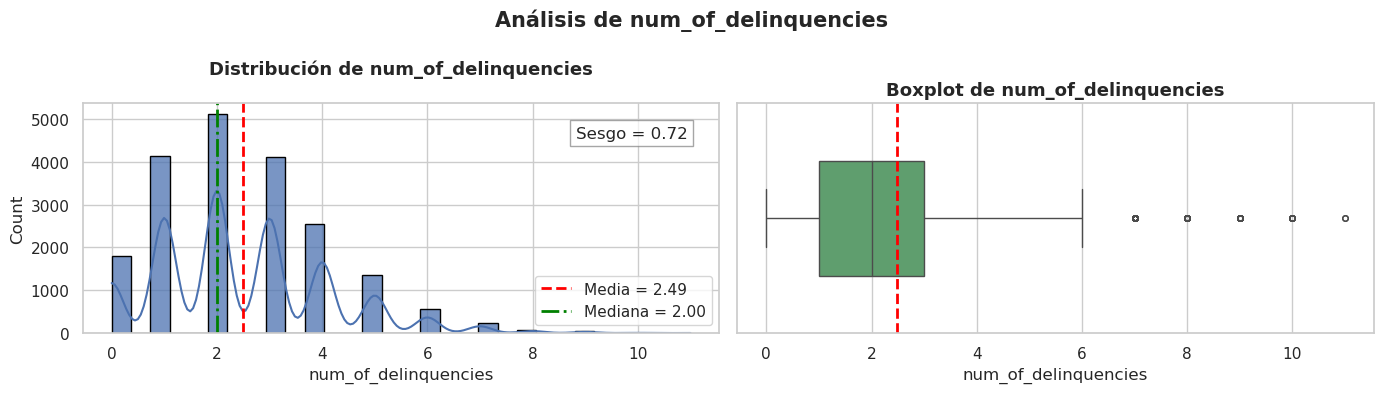

In [9]:
plot_distribucion_box(df, numeric_cols)

## Variables Categoricas

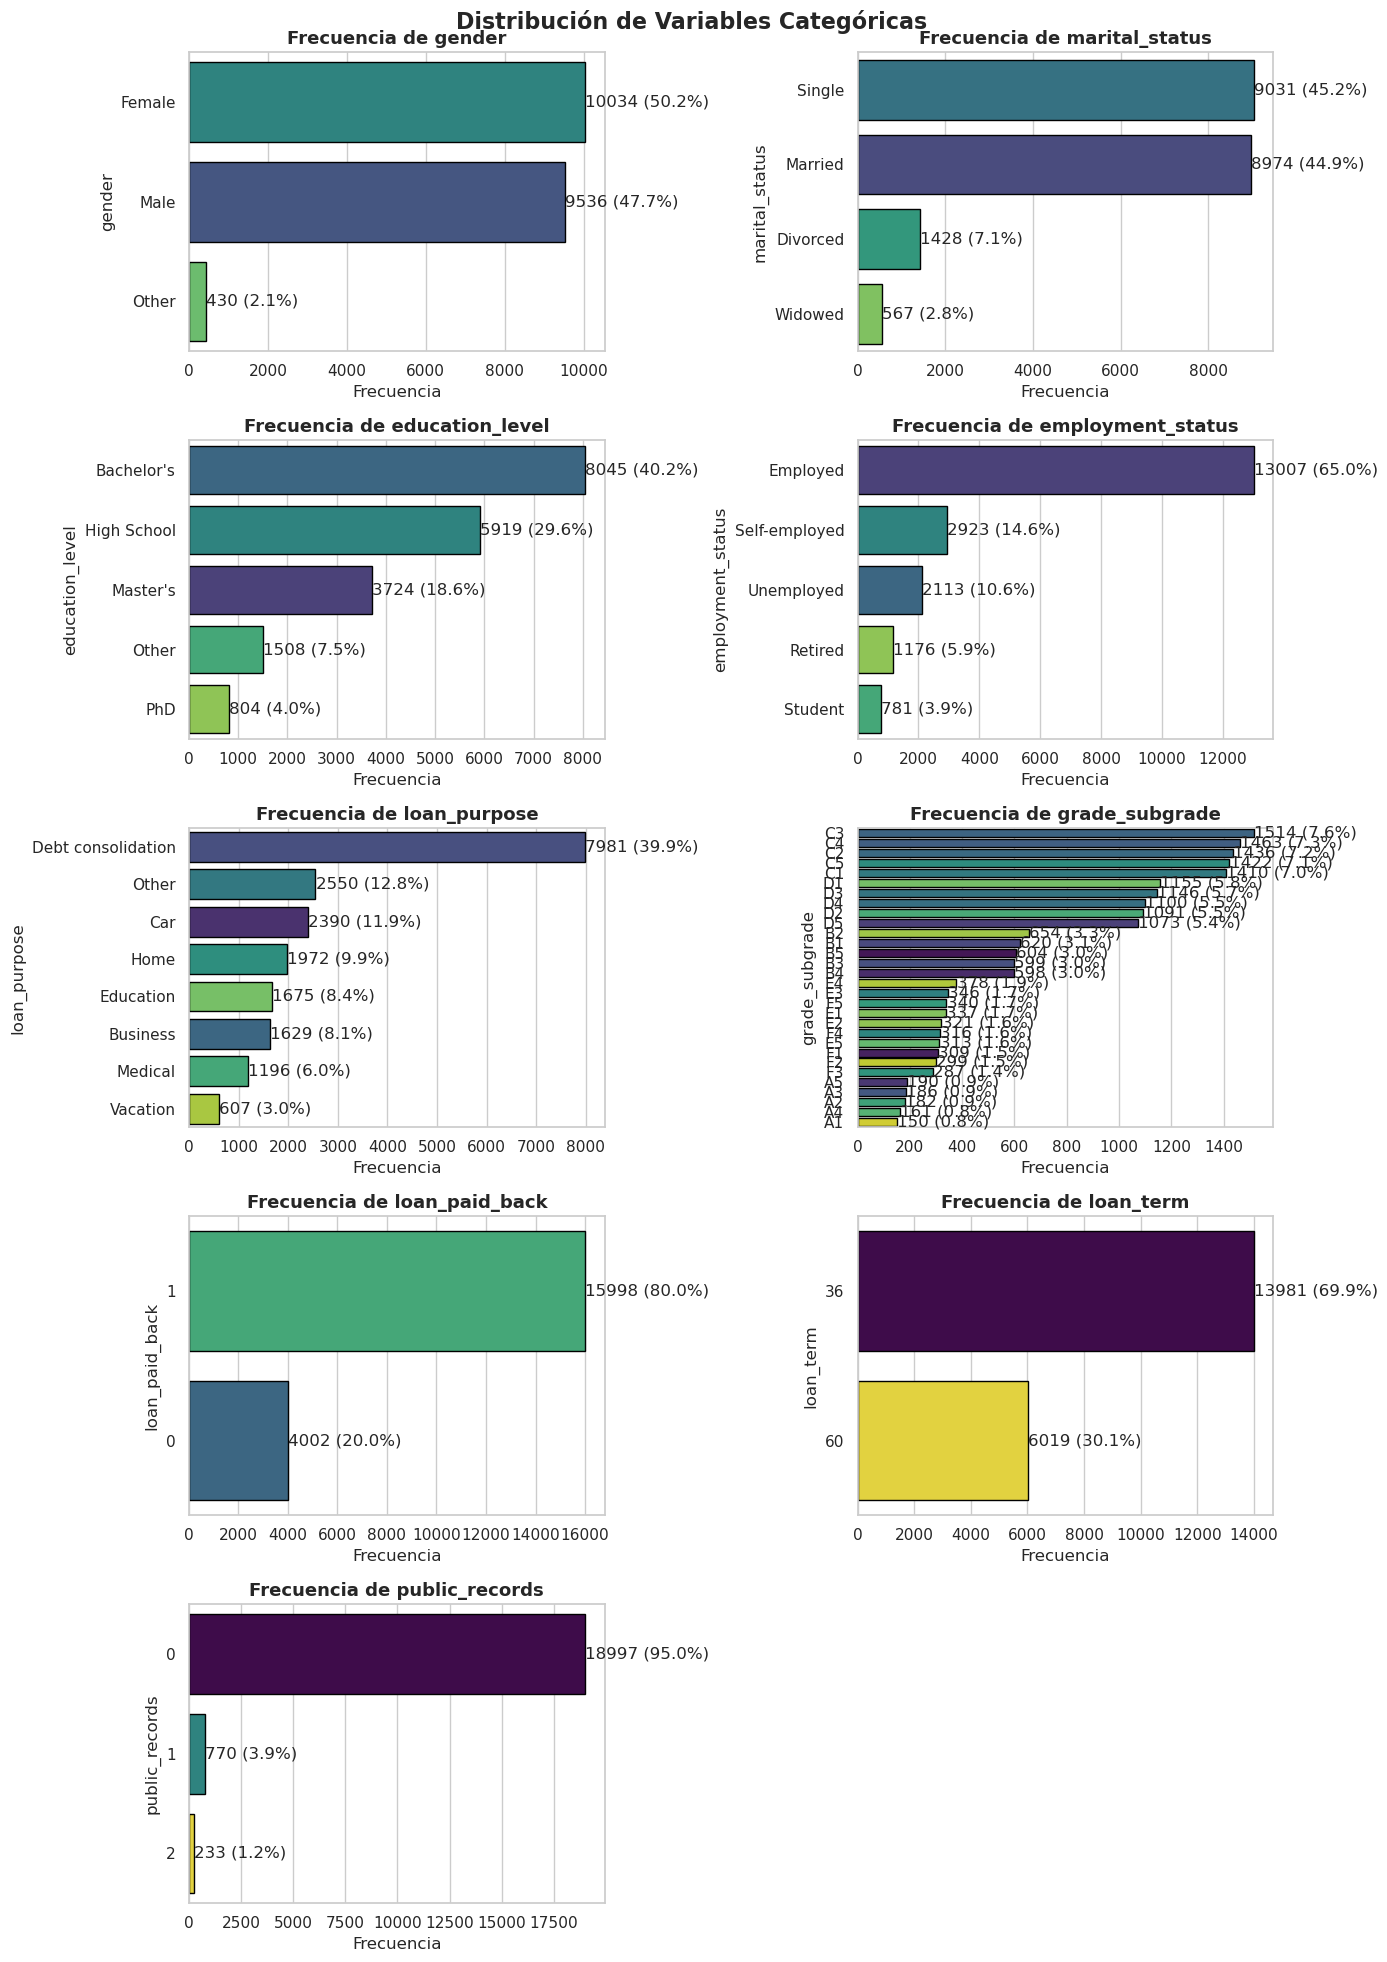

In [10]:
plot_frecuencias_categoricas(df, categoric_cols, show_percentage=True)

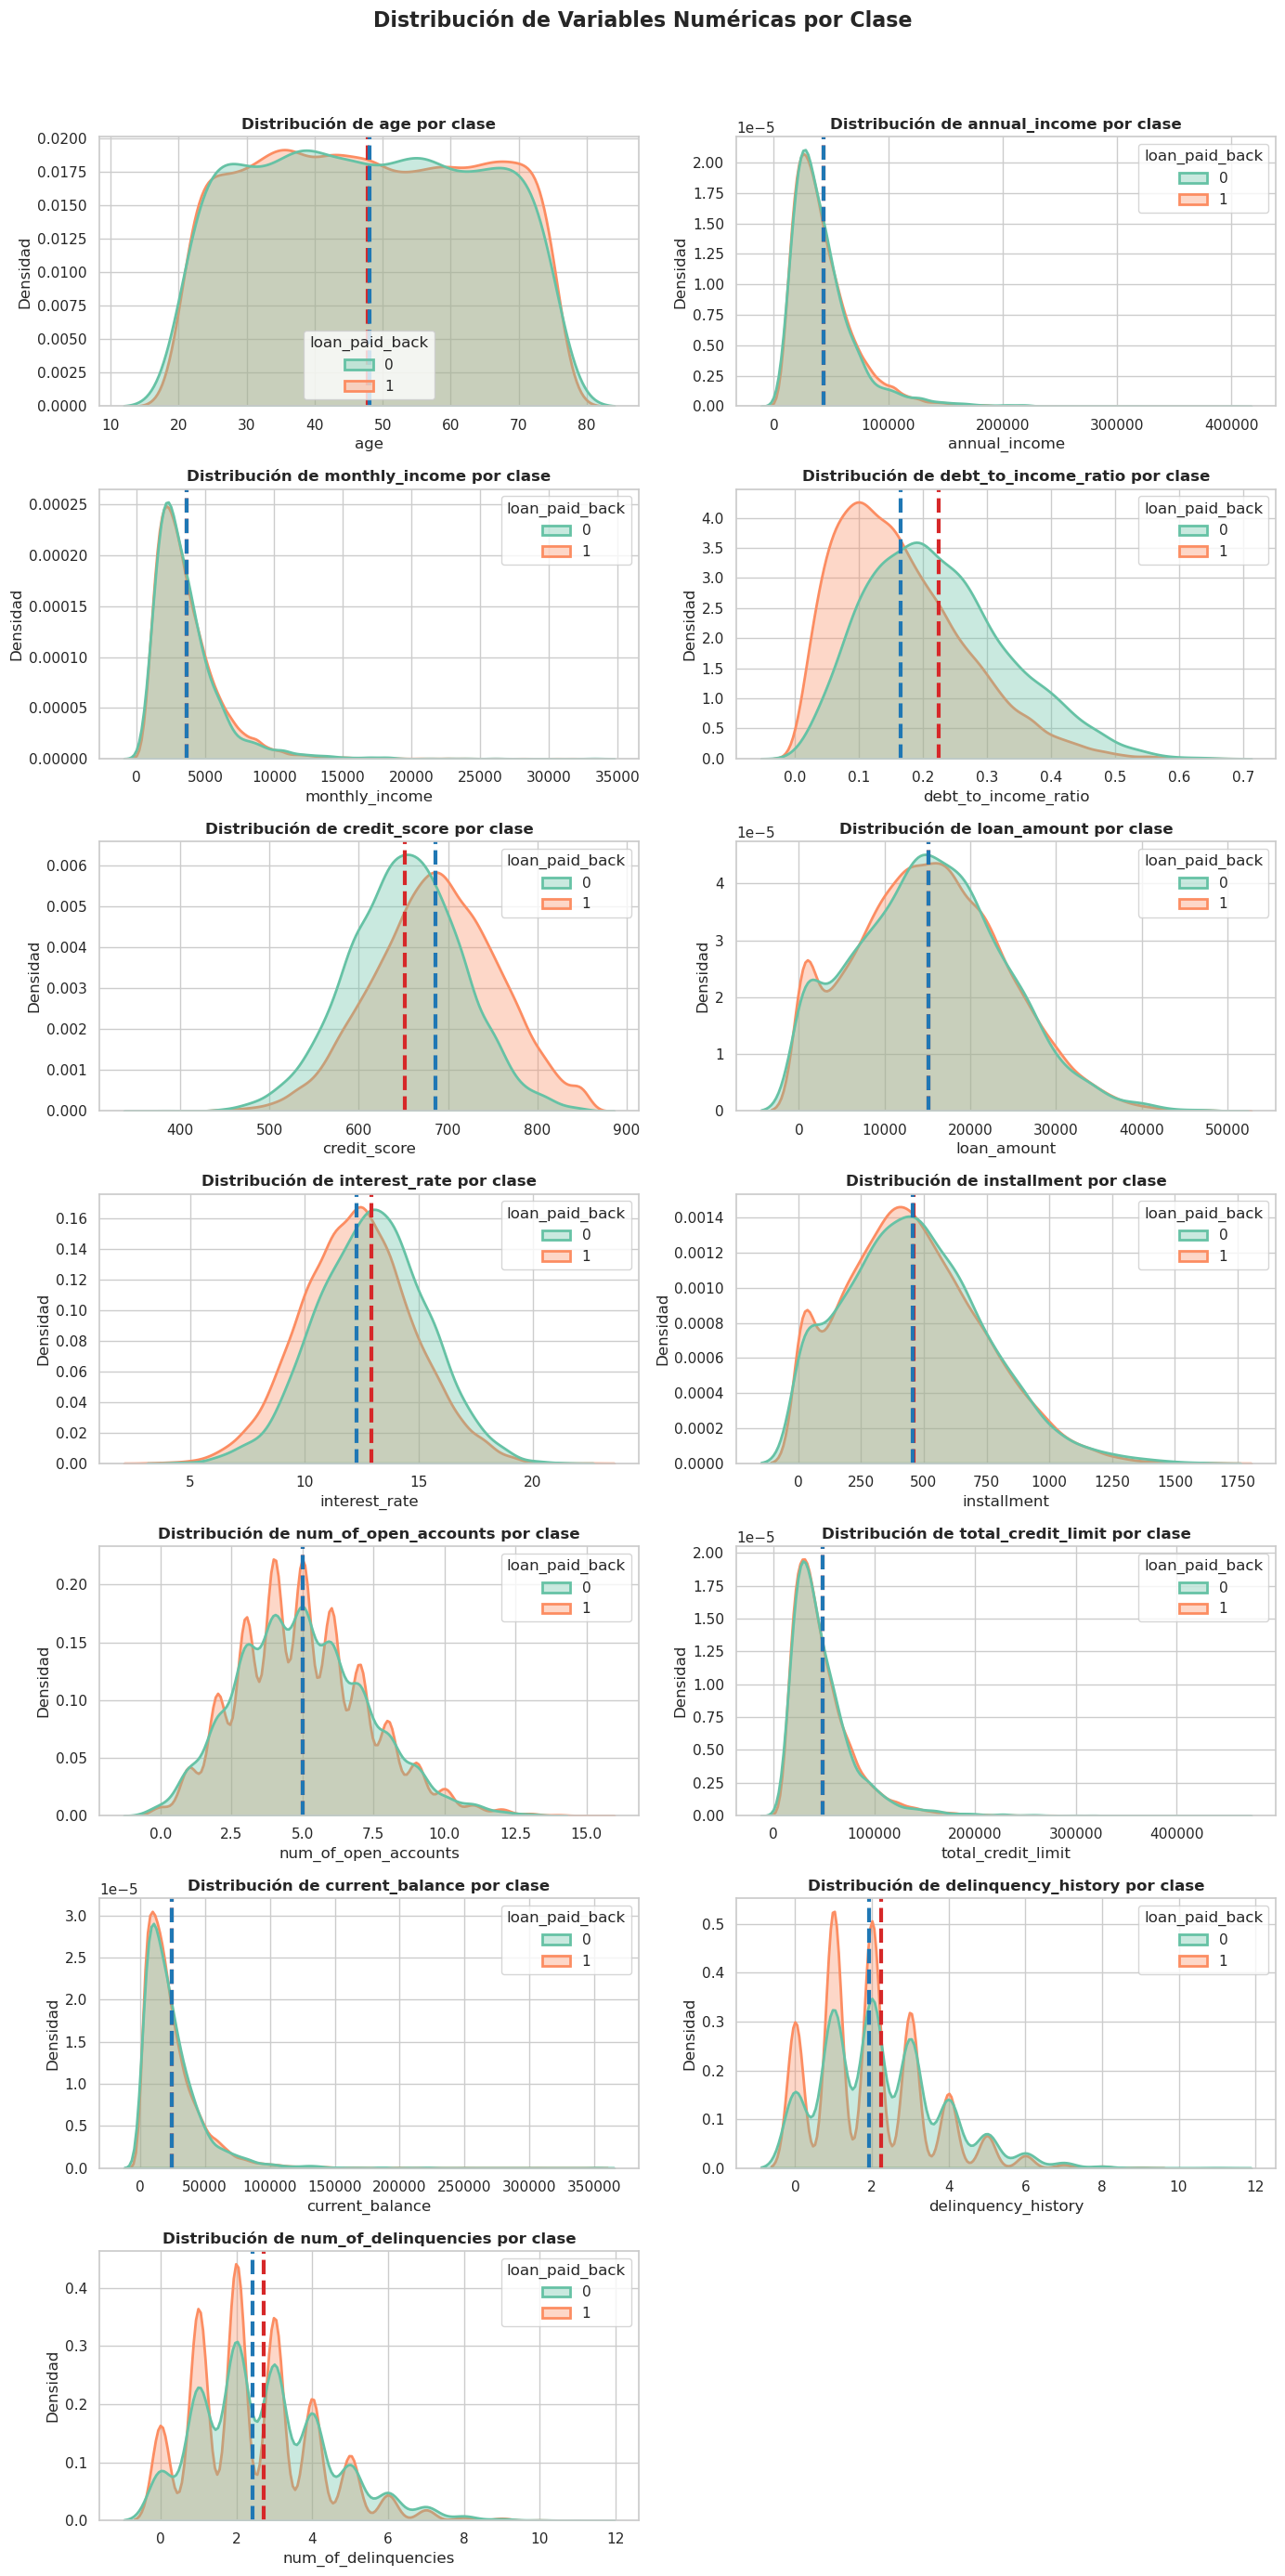

In [11]:
plot_kde_por_clase(df, numeric_cols, variable_objetivo)

### Proporción de pago por nivel educativo

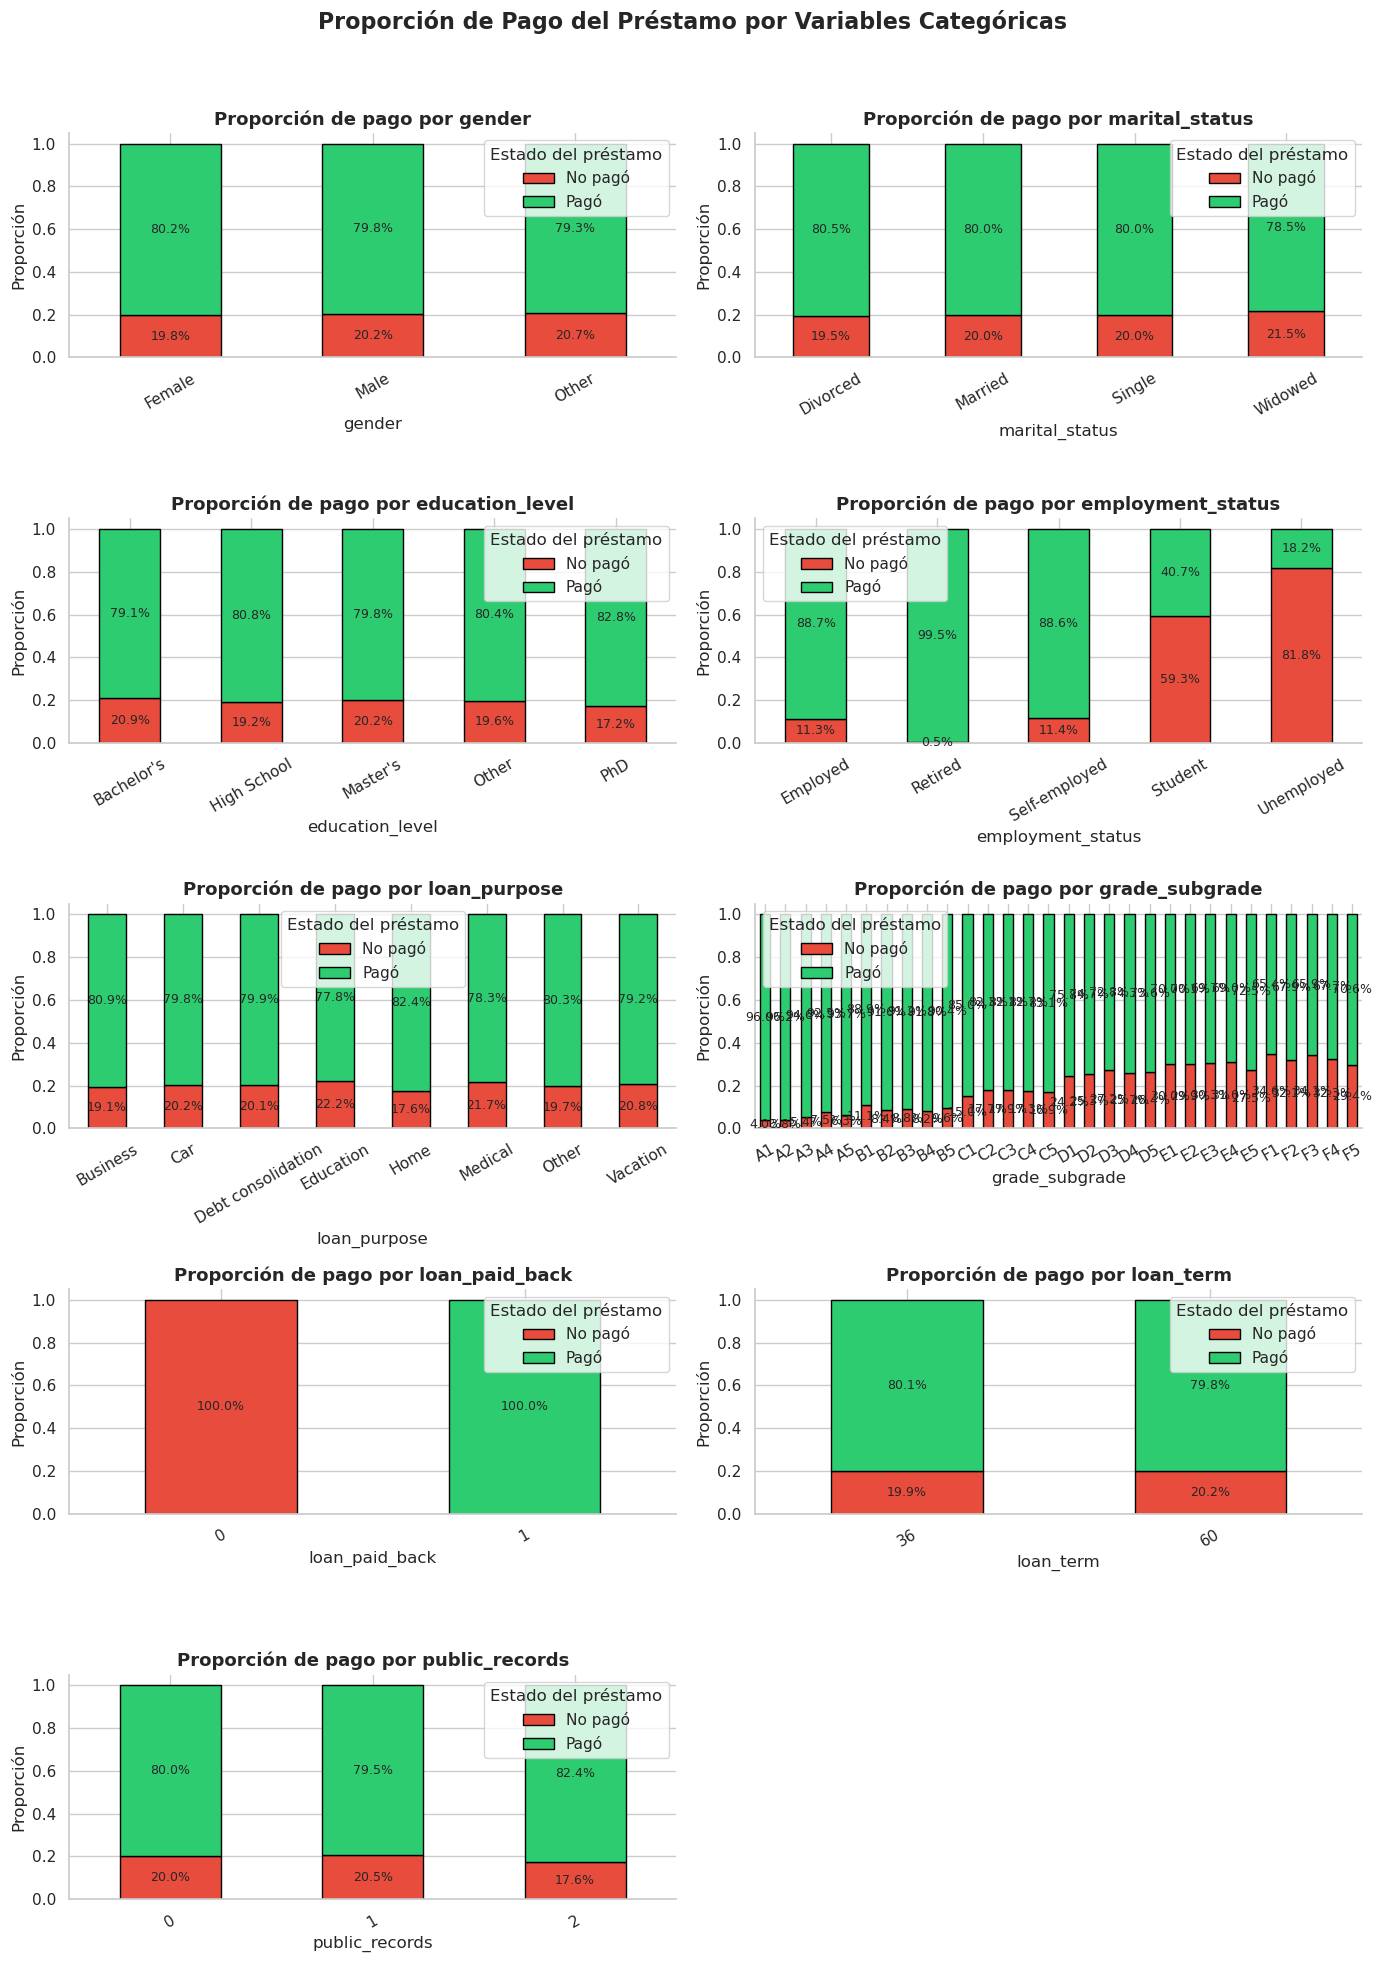

In [12]:
plot_crosstab_categoricas(
    df,
    categoric_cols,
    target=variable_objetivo
)

### Análisis multivariado con el target

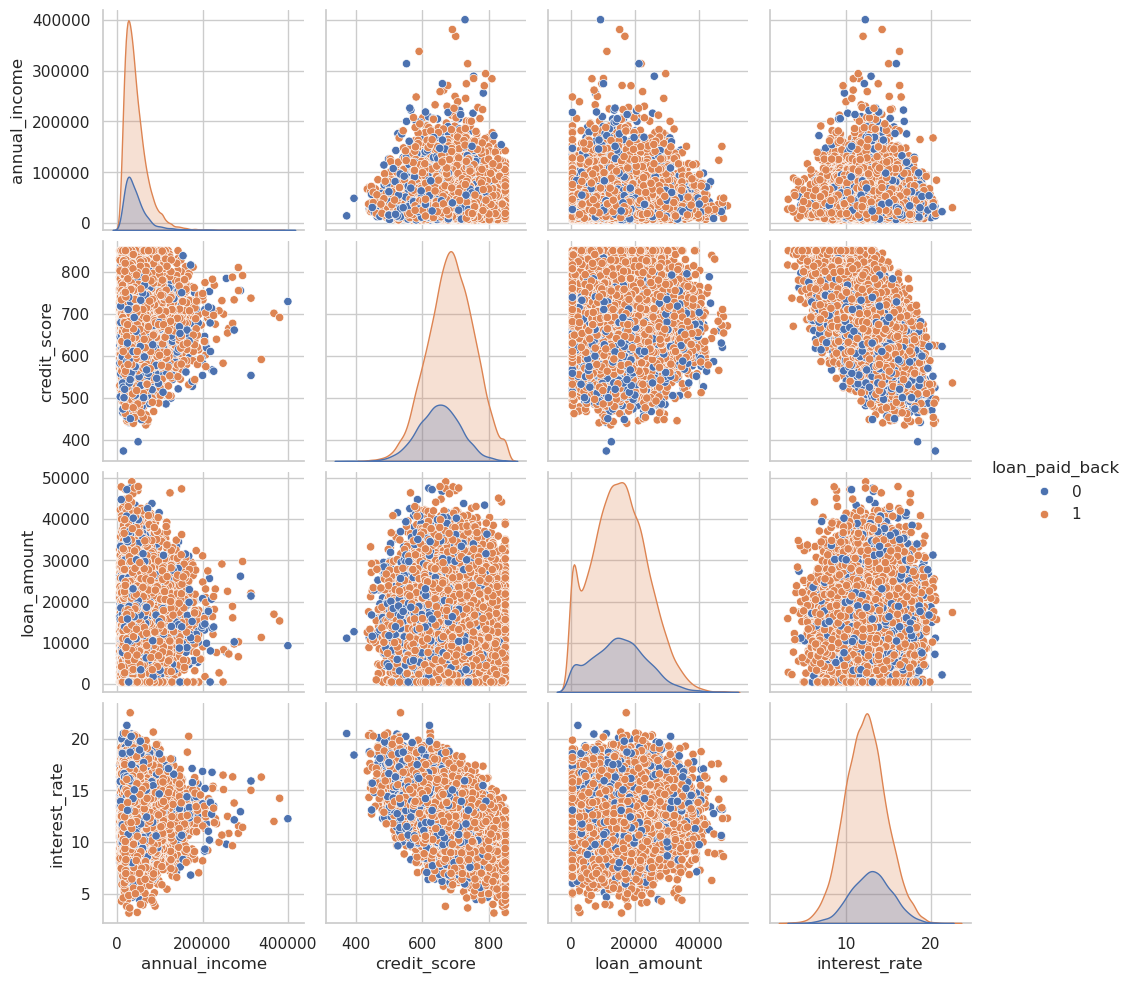

In [ ]:
sns.pairplot(df, vars=['annual_income', 'credit_score', 'loan_amount', 'interest_rate'], 
             hue='loan_paid_back', diag_kind='kde')
plt.show()

### Matriz de correlación

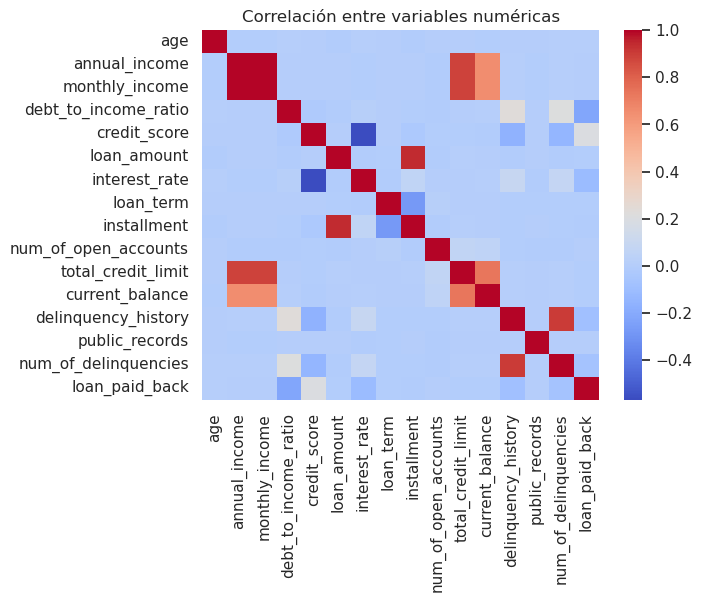

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

### Diferencia de medias estandarizada

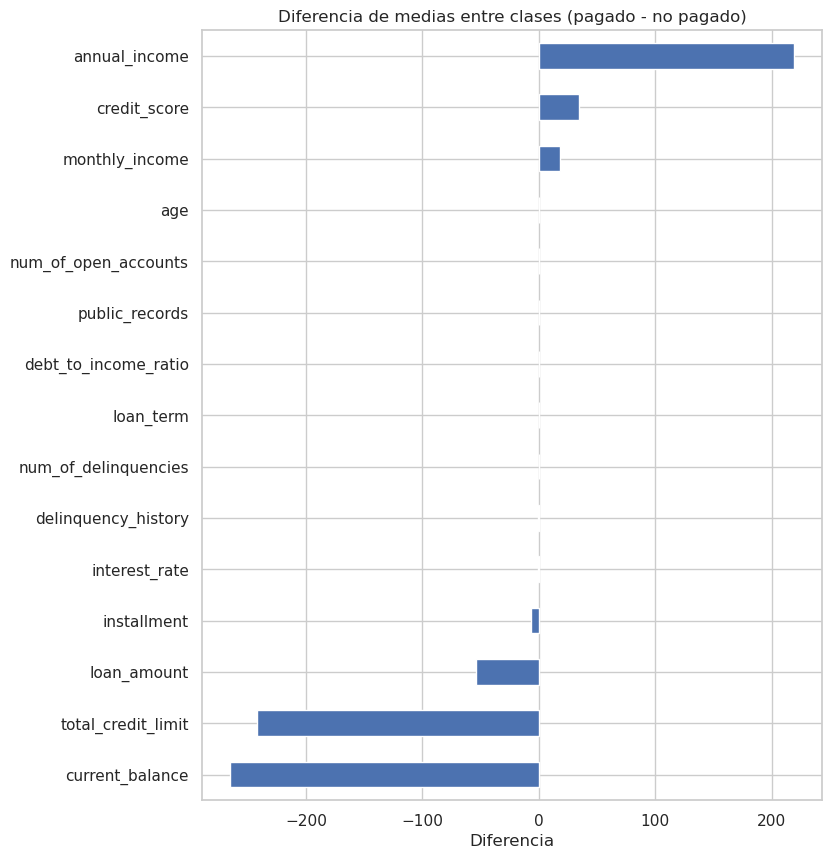

In [ ]:
diff_means = df.groupby('loan_paid_back').mean(numeric_only=True).T
diff_means['diferencia'] = diff_means[1] - diff_means[0]
diff_means['diferencia'].sort_values().plot(kind='barh', figsize=(8, 10))
plt.title('Diferencia de medias entre clases (pagado - no pagado)')
plt.xlabel('Diferencia')
plt.show()